In [6]:
%%html
<script>//Needs to be "nbsphinx" : "hidden"
MathJax.Hub.Config({
    TeX: { equationNumbers: {autoNumber: 'AMS'} }});
MathJax.Hub.Queue(
  ["resetEquationNumbers", MathJax.InputJax.TeX],
  ["PreProcess", MathJax.Hub],
  ["Reprocess", MathJax.Hub]
);
</script>

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Due to a Jupyter bug, the %matplotlib inline "magic" command needs to be in 
# its own cell. See:
# https://github.com/jupyter/notebook/issues/3385

%matplotlib inline

In [9]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 18}
matplotlib.rc('font', **font)

# Hypothesis testing

> There are two possible outcomes: if the result confirms the hypothesis, then you've made a measurement.

> If the result is contrary to the hypothesis, then you've made a discovery.

> Enrico Fermi

## Null hypothesis 

In classic statistics, we test a _null hypothesis_. 

This is sometimes written $H_0$ (not to be confused with the Hubble constant!).

Ideally, the null hypothesis and also significance at which we will reject it should be specified in advance of doing the test. 

(Not doing so is called "_a posteriori_ statistics"; more on this later.)

For example, the null hypothesis may be that the Riess and Planck Hubble parameters are consistent with each other.

How do we quantify this? 

The null hypothesis is that the difference between the two is zero. 

The alternative hypothesis is that this difference is not zero.

In [3]:
from uncertainties import ufloat
riess = ufloat(73.2, 1.3) # 2021 update
planck = ufloat(67.66, 0.42)
diff = riess - planck

print(f'The difference between Riess et al and Planck is {diff}')
print(f'This is a {diff.n/diff.s:.2f} sigma discrepancy')
from scipy.stats import norm

# Why the funny formula below?
p = 2*(1.-norm.cdf(diff.n/diff.s))
print("The p-value is:",p)
cl = 1-p
print('Zero rejected at the {:.3f}% CL'.format(cl*100.)) 

The difference between Riess et al and Planck is 5.5+/-1.4
This is a 4.06 sigma discrepancy
The p-value is: 5.010118333093061e-05
Zero rejected at the 99.995% CL


Therefore the null hypothesis is ruled out (at a high confidence level) for this *two-tailed* test.

## $p$-values

The $p$-value is the probability that the statistic would arise by chance under the null hypothesis.

Generally, the largest $p$-value that you should consider as being significant is 0.05. Indeed the ASA says "a $p$-value near 0.05 taken by itself offers only _weak_ evidence against the null hypothesis."

Larger $p$-values would not allow a significant rejection of the null hypothesis. Nor should they ever be considered as confirmation of the null hypothesis.

## Type I and Type II Errors

Of course, sometimes your rejection of the null hypothesis will turn out to be incorrect. 

Ideally, this will happen on a small fraction of the time. This is called a False Positive or Type I error. 

| Test Status | $H_0$ True | $H_0$ False | 
| --- | --- | --- |
| Test does **not** reject: | Correct Inference | False Negative (Type II) | 
| Test **does** reject: | False Positive (Type I) | Correct Inference | 

It is impossible to eliminate completely these errors. 

Moreover, if we reduce the threshold $p$-value to minimise the chance of a False Positive, we will almost certainly increase the chance of a False Negative.

## Checking for correlation

Often we would like to know if two variables are correlated with each other. This can be an important clue to the underlying physics.

Let's consider the following [table](http://tylervigen.com/spurious-correlations) which includes the divorce rate in the state of Maine versus consumption of margarine

In [4]:
# one way to read tables is astropy. You may need to install it
import astropy.table

tab = astropy.table.Table.read('divorce_margarine.csv',format='ascii.csv')
print(tab['Margarine'])

Margarine
---------
      8.2
      7.0
      6.5
      5.3
      5.2
      4.0
      4.6
      4.5
      4.2
      3.7


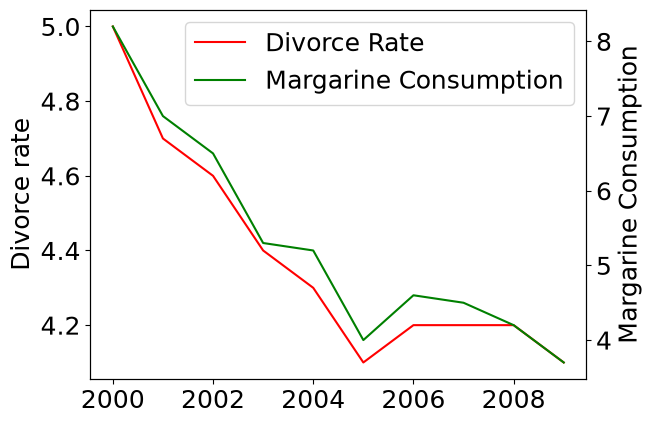

In [10]:
# Plot divorce rates and margarine on same plot
fig, ax1 = plt.subplots()
ax1.plot(tab['Year'],tab['Divorce'], 'r', label='Divorce Rate')
ax2 = ax1.twinx()
ax2.plot(tab['Year'],tab['Margarine'], 'g', label='Margarine Consumption')
ax1.set_ylabel("Divorce rate")
ax2.set_ylabel("Margarine Consumption")
# ask matplotlib for the plotted objects and their labels
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc=0);

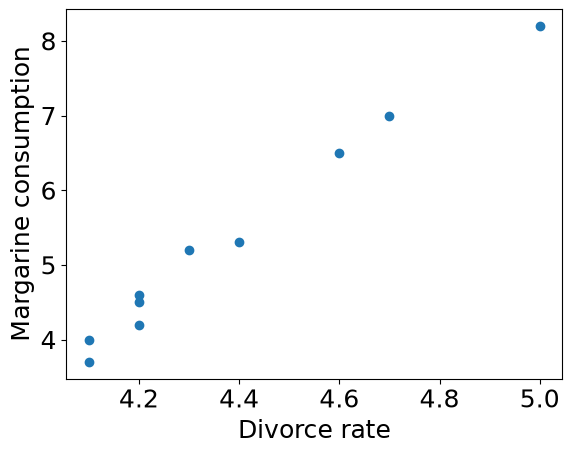

In [11]:
plt.scatter(tab['Divorce'], tab['Margarine'])
plt.xlabel('Divorce rate')
plt.ylabel('Margarine consumption');

In [12]:
import scipy.stats
r, p =scipy.stats.pearsonr(tab['Divorce'], tab['Margarine'])
print("Pearson's r is:",r)

Pearson's r is: 0.9925584582238185


To assess the significance of Pearson's $r$ statistic, we first need to transform it to its corresponding $t$ value:

$$
t = r \sqrt{\frac{N-2}{1-r^2}}
$$

The $t$-value is distributed according to Student's t-distribution with $N-2$ degrees of freedom. You need to look this up in a table or use ``scipy.stats``

In [13]:
N = len(tab['Divorce']) # get number of data points
t_value = r*np.sqrt((N-2)/(1-r**2)) # calculate t value
print("The Student t value of this is:", t_value)

The Student t value of this is: 23.054944982052625


In [14]:
from scipy.stats import t
dof = N-2
rv = t(dof)

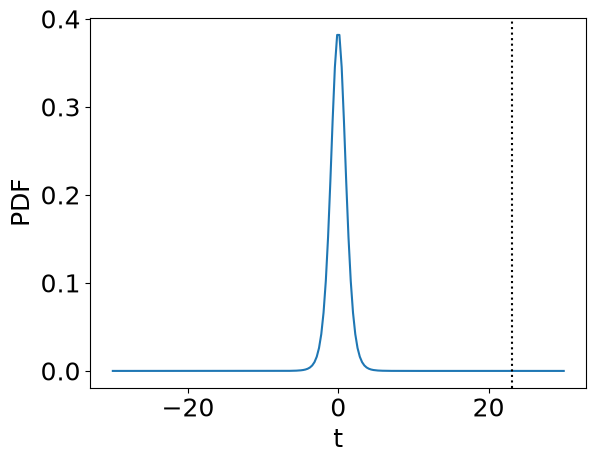

In [15]:
x = np.linspace(-30,30.,200)
plt.plot(x, rv.pdf(x))
plt.axvline(t_value, ls=':',c='k')
plt.xlabel('t')
plt.ylabel('PDF');

Pretty hard to see what's going on there but the probability is low. Let's try a log plot.

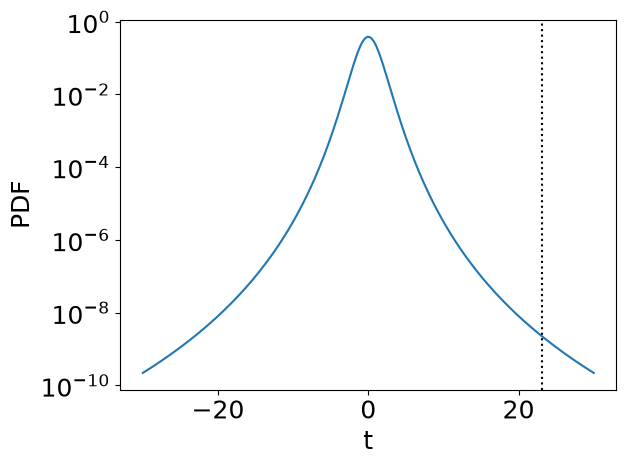

In [16]:
plt.semilogy(x, rv.pdf(x))
plt.axvline(t_value, ls=':',c='k')
plt.xlabel('t')
plt.ylabel('PDF');

Yup, it's low. Anyway, what we want in order to evaluate the significance is the area in the tails, i.e. the CDF

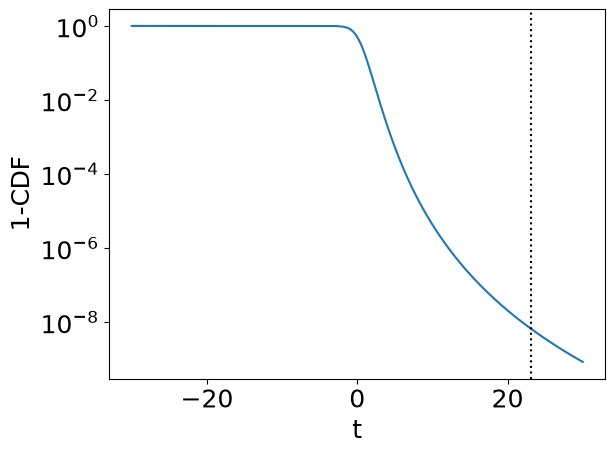

In [17]:
plt.semilogy(x, 1.-rv.cdf(x))
plt.axvline(t_value, ls=':',c='k')
plt.xlabel('t')
plt.ylabel('1-CDF');

In [18]:
p_value=2*(1.-rv.cdf(t_value))
print("The p_value is:", p_value)

The p_value is: 1.3296773460069744e-08


Pretty low value ... so apparently the correlation is highly significant!

***

**BUT:** Does divorce lead to increased margarine consumption? 

Or does increased margarine consumption lead to divorce?

Or maybe a third thing (depression?) causes both?

_Correlation does not imply causation_

***

![Correlation](https://imgs.xkcd.com/comics/correlation.png)
from [xkcd](https://xkcd.com/552/)

"But, wait a minute!" you say ... it's quite odd to correlate divorce rates and margarine consumption.

Was that _really_ your hypothesis?

Or is this a case of _a posteriori_ statistics?

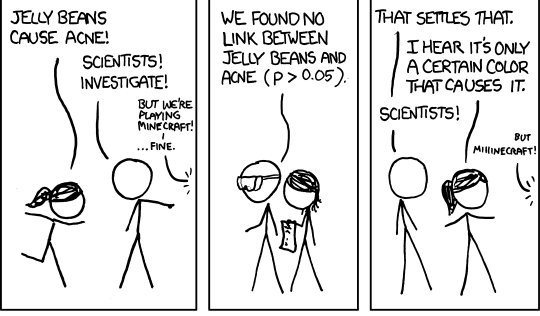

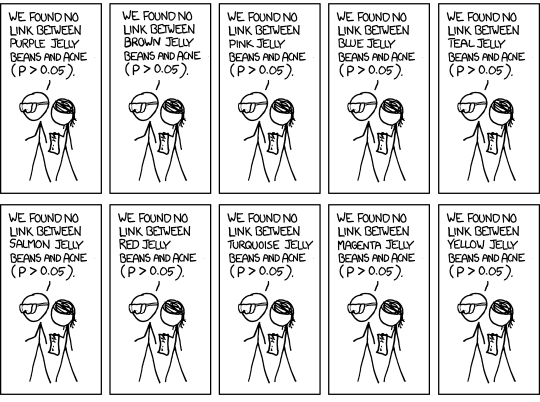

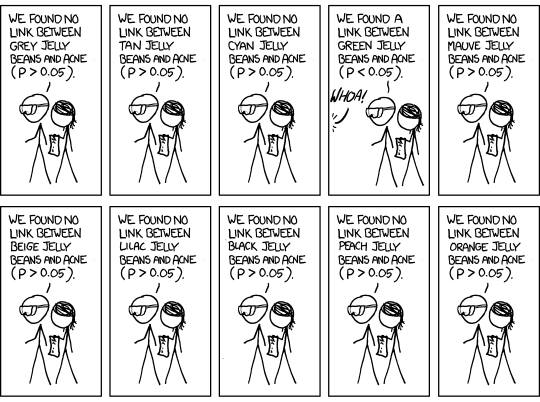

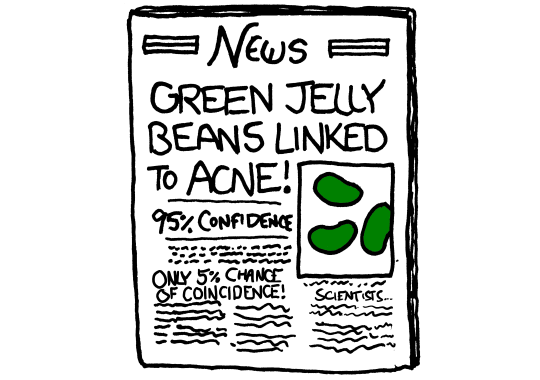

The problem of "fishing" in your data for "significant" correlations after they have been collected is known as "_a posteriori_ statistics", "data dredging", "significance chasing", "selective inference", and “p-hacking,” or, in some circumstances, as the "look-elsewhere effect."